# Matrix-Matrix Multiplication: Composing Transformations

When we multiply two matrices, we're **composing** (chaining) their transformations:

$$\mathbf{C} = \mathbf{A} \mathbf{B}$$

Means: "First apply $\mathbf{B}$, then apply $\mathbf{A}$"

### The Shape Rule
$$(m \times n) \cdot (n \times p) = (m \times p)$$

The inner dimensions must match, and they "cancel out" in the result.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import FancyArrowPatch, Polygon

np.random.seed(42)
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 11

---
## 1. Three Ways to Compute Matrix Multiplication

There are multiple equivalent views of $\mathbf{C} = \mathbf{A} \mathbf{B}$:

1. **Element-wise (dot products)**: $C_{ij} = \text{row}_i(\mathbf{A}) \cdot \text{col}_j(\mathbf{B})$
2. **Column-wise**: Column $j$ of $\mathbf{C}$ = $\mathbf{A}$ × (column $j$ of $\mathbf{B}$)
3. **Outer products**: $\mathbf{C} = \sum_k (\text{col}_k \mathbf{A}) (\text{row}_k \mathbf{B})$

In [2]:
# Simple example
A = np.array([[1, 2], 
              [3, 4]])
B = np.array([[5, 6], 
              [7, 8]])

print("A =")
print(A)
print("\nB =")
print(B)
print("\nC = A @ B =")
print(A @ B)

A =
[[1 2]
 [3 4]]

B =
[[5 6]
 [7 8]]

C = A @ B =
[[19 22]
 [43 50]]


In [3]:
# View 1: Element-wise (dot products)
print("View 1: Each element is a dot product")
print("="*50)
C = A @ B
for i in range(2):
    for j in range(2):
        row = A[i, :]
        col = B[:, j]
        print(f"C[{i},{j}] = row_{i}(A) · col_{j}(B) = {row} · {col} = {row @ col}")
print(f"\nResult:\n{C}")

View 1: Each element is a dot product
C[0,0] = row_0(A) · col_0(B) = [1 2] · [5 7] = 19
C[0,1] = row_0(A) · col_1(B) = [1 2] · [6 8] = 22
C[1,0] = row_1(A) · col_0(B) = [3 4] · [5 7] = 43
C[1,1] = row_1(A) · col_1(B) = [3 4] · [6 8] = 50

Result:
[[19 22]
 [43 50]]


In [4]:
# View 2: Column-wise
print("View 2: Each column of C = A × (column of B)")
print("="*50)
for j in range(2):
    col_B = B[:, j]
    col_C = A @ col_B
    print(f"C[:, {j}] = A @ B[:, {j}] = A @ {col_B} = {col_C}")
print(f"\nResult:\n{C}")

View 2: Each column of C = A × (column of B)
C[:, 0] = A @ B[:, 0] = A @ [5 7] = [19 43]
C[:, 1] = A @ B[:, 1] = A @ [6 8] = [22 50]

Result:
[[19 22]
 [43 50]]


In [5]:
# View 3: Sum of outer products
print("View 3: Sum of outer products")
print("="*50)
C_accumulated = np.zeros((2, 2))
for k in range(2):
    outer_k = np.outer(A[:, k], B[k, :])
    C_accumulated += outer_k
    print(f"k={k}: col_{k}(A) ⊗ row_{k}(B) = {A[:, k]} ⊗ {B[k, :]} =")
    print(outer_k)
    print()
print(f"Sum = \n{C_accumulated}")

View 3: Sum of outer products
k=0: col_0(A) ⊗ row_0(B) = [1 3] ⊗ [5 6] =
[[ 5  6]
 [15 18]]

k=1: col_1(A) ⊗ row_1(B) = [2 4] ⊗ [7 8] =
[[14 16]
 [28 32]]

Sum = 
[[19. 22.]
 [43. 50.]]


---
## 2. Composition of Transformations

The key geometric insight: $\mathbf{AB}$ means "first B, then A".

$$\mathbf{y} = \mathbf{A}(\mathbf{B}\mathbf{x}) = (\mathbf{AB})\mathbf{x}$$

We can pre-compute $\mathbf{C} = \mathbf{AB}$ and apply it in one step!

In [6]:
# Define two transformations
theta = np.pi/4  # 45 degrees
R = np.array([[np.cos(theta), -np.sin(theta)], 
              [np.sin(theta), np.cos(theta)]])  # Rotation

S = np.array([[2, 0], 
              [0, 0.5]])  # Scaling

# Compose: first scale, then rotate
RS = R @ S  # Combined transformation

print("S (scaling):")
print(S)
print("\nR (rotation 45°):")
print(R.round(3))
print("\nRS = R @ S (first scale, then rotate):")
print(RS.round(3))

S (scaling):
[[2.  0. ]
 [0.  0.5]]

R (rotation 45°):
[[ 0.707 -0.707]
 [ 0.707  0.707]]

RS = R @ S (first scale, then rotate):
[[ 1.414 -0.354]
 [ 1.414  0.354]]


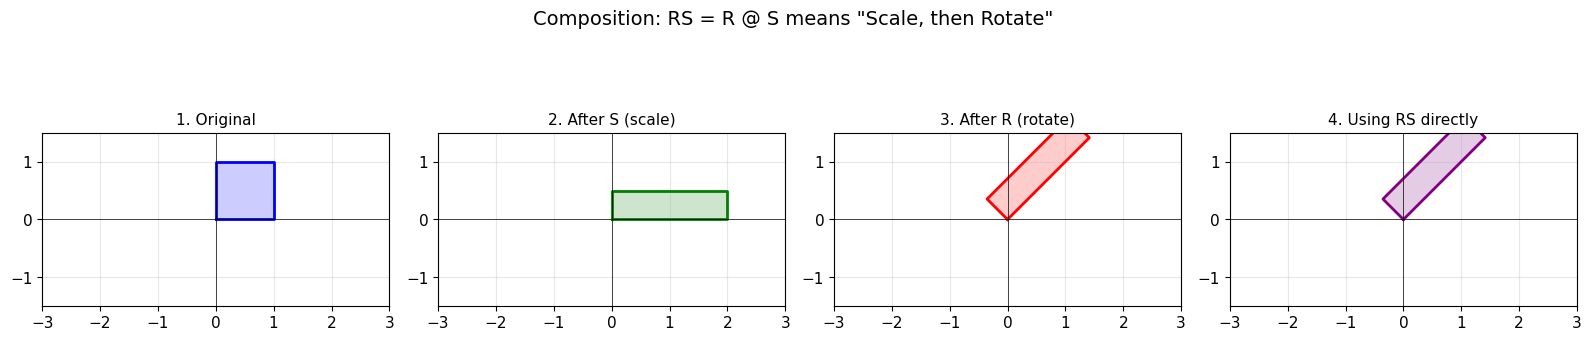

Results match: True


In [7]:
# Visualize the composition
fig, axes = plt.subplots(1, 4, figsize=(16, 4))

# Create a unit square with some points
square = np.array([[0, 1, 1, 0, 0], 
                   [0, 0, 1, 1, 0]])

# Helper function
def plot_shape(ax, shape, title, color='blue'):
    ax.plot(shape[0], shape[1], color=color, linewidth=2)
    ax.fill(shape[0], shape[1], alpha=0.2, color=color)
    ax.set_xlim(-3, 3)
    ax.set_ylim(-1.5, 1.5)
    ax.set_aspect('equal')
    ax.grid(True, alpha=0.3)
    ax.axhline(y=0, color='black', linewidth=0.5)
    ax.axvline(x=0, color='black', linewidth=0.5)
    ax.set_title(title, fontsize=11)

# Original
plot_shape(axes[0], square, '1. Original')

# After scaling
scaled = S @ square
plot_shape(axes[1], scaled, '2. After S (scale)', 'green')

# After rotation (of scaled)
rotated_scaled = R @ scaled
plot_shape(axes[2], rotated_scaled, '3. After R (rotate)', 'red')

# Using combined matrix
combined = RS @ square
plot_shape(axes[3], combined, '4. Using RS directly', 'purple')

plt.suptitle('Composition: RS = R @ S means "Scale, then Rotate"', fontsize=14)
plt.tight_layout()
plt.show()

print(f"Results match: {np.allclose(rotated_scaled, combined)}")

---
## 3. Order Matters! (Non-Commutativity)

Unlike scalar multiplication, matrix multiplication is **not commutative**:

$$\mathbf{AB} \neq \mathbf{BA}$$ (in general)

"First rotate then scale" gives a different result than "first scale then rotate"!

In [8]:
# Show non-commutativity
SR = S @ R  # First rotate, then scale
RS = R @ S  # First scale, then rotate

print("SR = S @ R (first rotate, then scale):")
print(SR.round(3))
print("\nRS = R @ S (first scale, then rotate):")
print(RS.round(3))
print(f"\nAre they equal? {np.allclose(SR, RS)}")

SR = S @ R (first rotate, then scale):
[[ 1.414 -1.414]
 [ 0.354  0.354]]

RS = R @ S (first scale, then rotate):
[[ 1.414 -0.354]
 [ 1.414  0.354]]

Are they equal? False


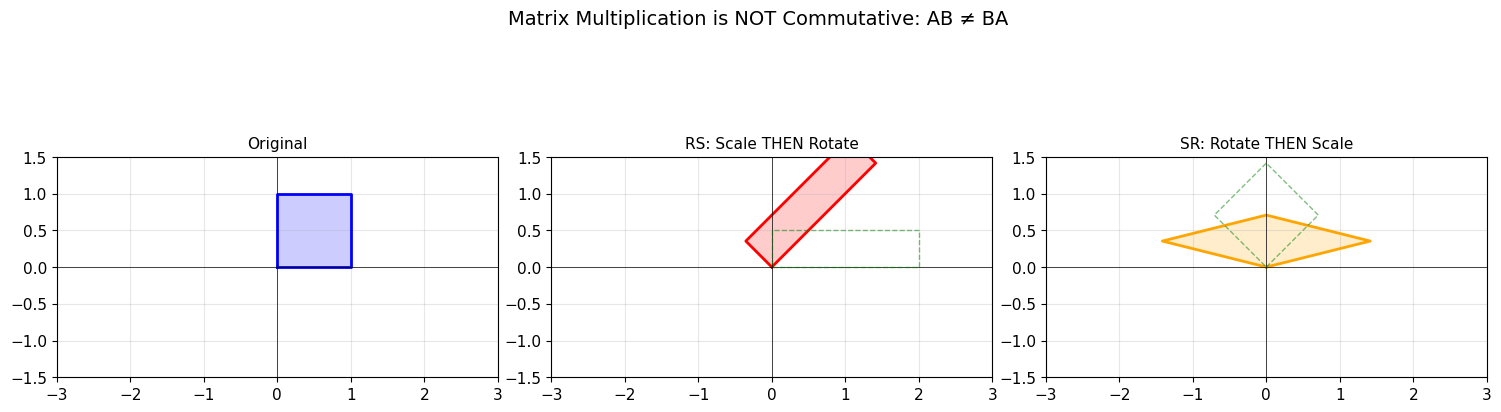

In [9]:
# Visualize the difference
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Original
plot_shape(axes[0], square, 'Original', 'blue')

# RS: scale then rotate
RS_result = RS @ square
plot_shape(axes[1], RS_result, 'RS: Scale THEN Rotate', 'red')
# Also show the intermediate step
scaled = S @ square
axes[1].plot(scaled[0], scaled[1], 'g--', linewidth=1, alpha=0.5)

# SR: rotate then scale  
SR_result = SR @ square
plot_shape(axes[2], SR_result, 'SR: Rotate THEN Scale', 'orange')
# Show intermediate
rotated = R @ square
axes[2].plot(rotated[0], rotated[1], 'g--', linewidth=1, alpha=0.5)

plt.suptitle('Matrix Multiplication is NOT Commutative: AB ≠ BA', fontsize=14)
plt.tight_layout()
plt.show()

---
## Real-World Scenario: Image Processing Pipeline

**Scenario**: You're building an image processing app. Each filter (blur, sharpen, edge detect) is a matrix operation. The order of filters matters!

- Blur then sharpen ≠ Sharpen then blur
- We can precompute combined filter matrices for efficiency

In [10]:
# Simplified 1D convolution as matrix multiplication
# For a signal of length 5, we can represent convolution as matrix-vector multiply

def create_conv_matrix(kernel, n):
    """Create a matrix that performs convolution with given kernel."""
    k = len(kernel)
    pad = k // 2
    M = np.zeros((n, n))
    for i in range(n):
        for j, w in enumerate(kernel):
            col = i + j - pad
            if 0 <= col < n:
                M[i, col] = w
    return M

n = 7  # Signal length

# Blur kernel: averaging
blur_kernel = np.array([0.25, 0.5, 0.25])
Blur = create_conv_matrix(blur_kernel, n)

# Sharpen kernel: edge enhancement
sharpen_kernel = np.array([-0.5, 2.0, -0.5])
Sharpen = create_conv_matrix(sharpen_kernel, n)

print("Blur matrix (averaging filter):")
print(Blur.round(2))
print("\nSharpen matrix (edge enhancement):")
print(Sharpen.round(2))

Blur matrix (averaging filter):
[[0.5  0.25 0.   0.   0.   0.   0.  ]
 [0.25 0.5  0.25 0.   0.   0.   0.  ]
 [0.   0.25 0.5  0.25 0.   0.   0.  ]
 [0.   0.   0.25 0.5  0.25 0.   0.  ]
 [0.   0.   0.   0.25 0.5  0.25 0.  ]
 [0.   0.   0.   0.   0.25 0.5  0.25]
 [0.   0.   0.   0.   0.   0.25 0.5 ]]

Sharpen matrix (edge enhancement):
[[ 2.  -0.5  0.   0.   0.   0.   0. ]
 [-0.5  2.  -0.5  0.   0.   0.   0. ]
 [ 0.  -0.5  2.  -0.5  0.   0.   0. ]
 [ 0.   0.  -0.5  2.  -0.5  0.   0. ]
 [ 0.   0.   0.  -0.5  2.  -0.5  0. ]
 [ 0.   0.   0.   0.  -0.5  2.  -0.5]
 [ 0.   0.   0.   0.   0.  -0.5  2. ]]


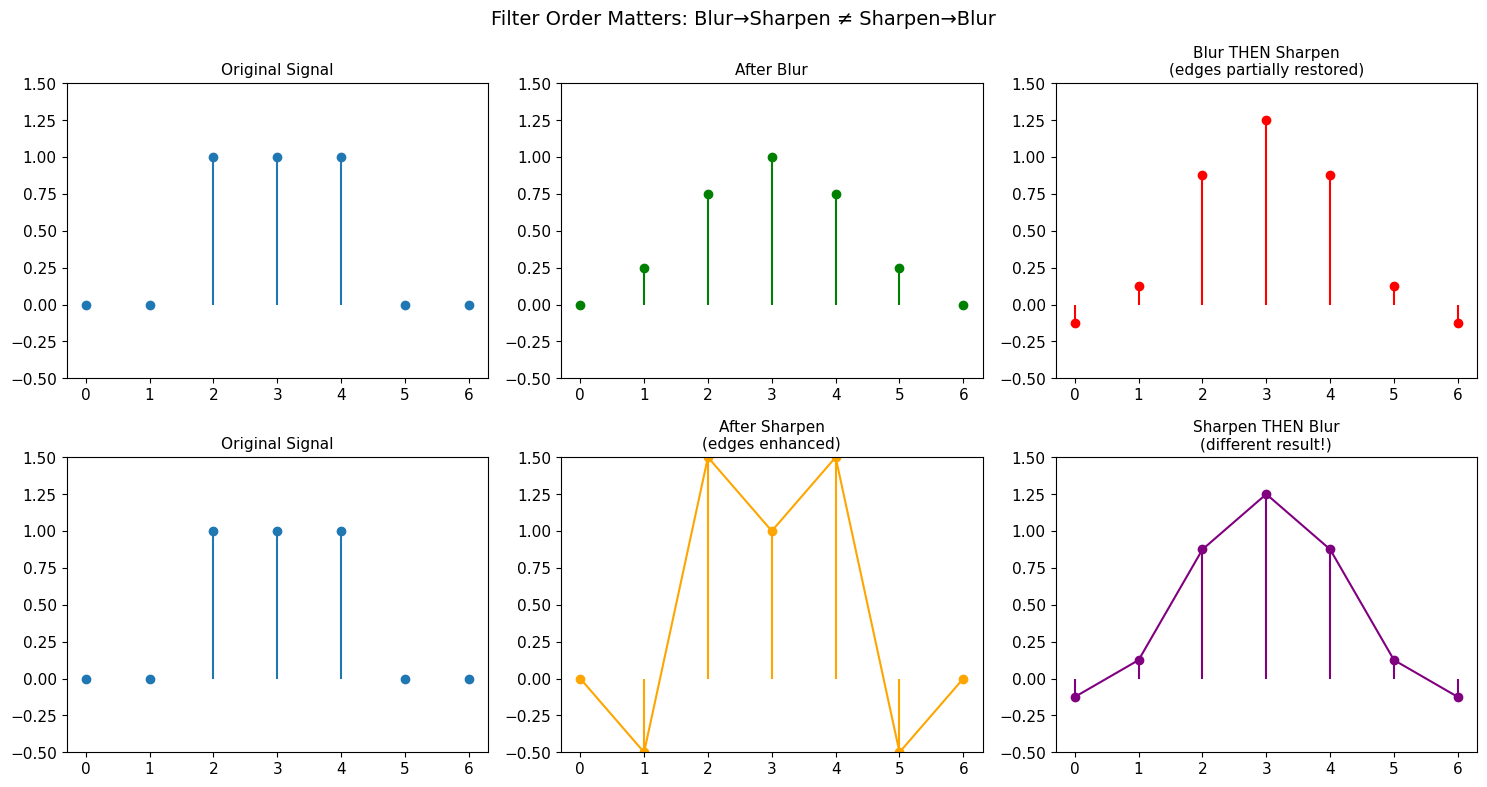

In [11]:
# Create a test signal with edges
signal = np.array([0, 0, 1, 1, 1, 0, 0], dtype=float)

# Apply filters in different orders
blur_then_sharpen = Sharpen @ (Blur @ signal)
sharpen_then_blur = Blur @ (Sharpen @ signal)

# Using combined matrices
SB = Sharpen @ Blur  # Blur then sharpen
BS = Blur @ Sharpen  # Sharpen then blur

fig, axes = plt.subplots(2, 3, figsize=(15, 8))

# Original
axes[0, 0].stem(signal, basefmt=' ')
axes[0, 0].set_title('Original Signal', fontsize=11)
axes[0, 0].set_ylim(-0.5, 1.5)

# After blur
blurred = Blur @ signal
axes[0, 1].stem(blurred, basefmt=' ', linefmt='g-', markerfmt='go')
axes[0, 1].set_title('After Blur', fontsize=11)
axes[0, 1].set_ylim(-0.5, 1.5)

# Blur then sharpen
axes[0, 2].stem(blur_then_sharpen, basefmt=' ', linefmt='r-', markerfmt='ro')
axes[0, 2].set_title('Blur THEN Sharpen\n(edges partially restored)', fontsize=11)
axes[0, 2].set_ylim(-0.5, 1.5)

# Second row: other order
axes[1, 0].stem(signal, basefmt=' ')
axes[1, 0].set_title('Original Signal', fontsize=11)
axes[1, 0].set_ylim(-0.5, 1.5)

# After sharpen
sharpened = Sharpen @ signal
axes[1, 1].stem(sharpened, basefmt=' ', linefmt='orange', markerfmt='o')
axes[1, 1].plot(sharpened, 'orange')
axes[1, 1].set_title('After Sharpen\n(edges enhanced)', fontsize=11)
axes[1, 1].set_ylim(-0.5, 1.5)

# Sharpen then blur
axes[1, 2].stem(sharpen_then_blur, basefmt=' ', linefmt='purple', markerfmt='o')
axes[1, 2].plot(sharpen_then_blur, 'purple')
axes[1, 2].set_title('Sharpen THEN Blur\n(different result!)', fontsize=11)
axes[1, 2].set_ylim(-0.5, 1.5)

plt.suptitle('Filter Order Matters: Blur→Sharpen ≠ Sharpen→Blur', fontsize=14)
plt.tight_layout()
plt.show()

---
## 4. Associativity and Efficiency

Matrix multiplication **is** associative:

$$\mathbf{A}(\mathbf{BC}) = (\mathbf{AB})\mathbf{C}$$

This means we can choose how to group operations for efficiency!

In [12]:
# Efficiency example: (A @ B) @ x vs A @ (B @ x)
# When x is a vector, it's much faster to do B @ x first!

n = 1000
A = np.random.randn(n, n)
B = np.random.randn(n, n)
x = np.random.randn(n)

# Count operations (conceptually)
print("Computing (AB)x vs A(Bx)")
print("="*50)
print(f"\nMethod 1: First compute C = A @ B, then C @ x")
print(f"  A @ B: {n}×{n}×{n} = {n**3:,} multiplications")
print(f"  C @ x: {n}×{n} = {n**2:,} multiplications")
print(f"  Total: {n**3 + n**2:,} multiplications")

print(f"\nMethod 2: First compute y = B @ x, then A @ y")
print(f"  B @ x: {n}×{n} = {n**2:,} multiplications")
print(f"  A @ y: {n}×{n} = {n**2:,} multiplications")
print(f"  Total: {2*n**2:,} multiplications")

print(f"\nSpeedup: {(n**3 + n**2) / (2*n**2):.0f}x fewer operations!")

Computing (AB)x vs A(Bx)

Method 1: First compute C = A @ B, then C @ x
  A @ B: 1000×1000×1000 = 1,000,000,000 multiplications
  C @ x: 1000×1000 = 1,000,000 multiplications
  Total: 1,001,000,000 multiplications

Method 2: First compute y = B @ x, then A @ y
  B @ x: 1000×1000 = 1,000,000 multiplications
  A @ y: 1000×1000 = 1,000,000 multiplications
  Total: 2,000,000 multiplications

Speedup: 500x fewer operations!


In [13]:
# Verify results are the same
method1 = (A @ B) @ x
method2 = A @ (B @ x)
print(f"Results are equal: {np.allclose(method1, method2)}")

Results are equal: True


---
## 5. Special Products

Some matrix products have special properties:

| Product | Formula | Property |
|---------|---------|----------|
| Symmetric product | $\mathbf{A}^T \mathbf{A}$ | Always symmetric positive semi-definite |
| Similarity transform | $\mathbf{P}^{-1} \mathbf{A} \mathbf{P}$ | Preserves eigenvalues |
| Orthogonal product | $\mathbf{Q}^T \mathbf{Q} = \mathbf{I}$ | Orthogonal matrices preserve lengths |

In [14]:
# A.T @ A is always symmetric positive semi-definite
A = np.random.randn(5, 3)  # Any matrix
ATA = A.T @ A

print("A.T @ A is always symmetric and positive semi-definite")
print("="*50)
print(f"\nA shape: {A.shape}")
print(f"A.T @ A shape: {ATA.shape}")
print(f"\nA.T @ A:")
print(ATA.round(3))
print(f"\nIs symmetric? {np.allclose(ATA, ATA.T)}")
print(f"Eigenvalues: {np.linalg.eigvalsh(ATA).round(3)}")
print(f"All eigenvalues ≥ 0? {all(np.linalg.eigvalsh(ATA) >= -1e-10)}")

A.T @ A is always symmetric and positive semi-definite

A shape: (5, 3)
A.T @ A shape: (3, 3)

A.T @ A:
[[ 5.73  -1.276  0.067]
 [-1.276  5.194  3.819]
 [ 0.067  3.819  3.428]]

Is symmetric? True
Eigenvalues: [0.257 5.531 8.565]
All eigenvalues ≥ 0? True


In [15]:
# Orthogonal matrices preserve lengths
theta = np.pi/3
Q = np.array([[np.cos(theta), -np.sin(theta)],
              [np.sin(theta), np.cos(theta)]])  # Rotation = orthogonal

print("Orthogonal matrix Q (rotation by 60°):")
print(Q.round(3))
print(f"\nQ.T @ Q = I:")
print((Q.T @ Q).round(10))

# Check length preservation
x = np.array([3, 4])  # Length 5
Qx = Q @ x
print(f"\nx = {x}, ||x|| = {np.linalg.norm(x)}")
print(f"Qx = {Qx.round(3)}, ||Qx|| = {np.linalg.norm(Qx):.6f}")
print(f"Length preserved: {np.isclose(np.linalg.norm(x), np.linalg.norm(Qx))}")

Orthogonal matrix Q (rotation by 60°):
[[ 0.5   -0.866]
 [ 0.866  0.5  ]]

Q.T @ Q = I:
[[ 1. -0.]
 [-0.  1.]]

x = [3 4], ||x|| = 5.0
Qx = [-1.964  4.598], ||Qx|| = 5.000000
Length preserved: True


---
## Key Takeaways

1. **Matrix multiplication** $\mathbf{C} = \mathbf{AB}$ composes transformations
   - Apply B first, then A (right to left)

2. **Three equivalent views**:
   - Element: $C_{ij} = \text{row}_i(A) \cdot \text{col}_j(B)$
   - Column: columns of C = A × (columns of B)
   - Outer products: sum of rank-1 matrices

3. **Not commutative**: $\mathbf{AB} \neq \mathbf{BA}$ in general
   - Order of operations matters!

4. **Is associative**: $(\mathbf{AB})\mathbf{C} = \mathbf{A}(\mathbf{BC})$
   - Choose grouping for efficiency

5. **Special products**:
   - $\mathbf{A}^T\mathbf{A}$ is always symmetric PSD
   - Orthogonal: $\mathbf{Q}^T\mathbf{Q} = \mathbf{I}$ (preserves lengths)

**Next**: We'll explore the **quadratic form** $\mathbf{x}^T \mathbf{W} \mathbf{x}$ — a pattern that measures "weighted distance."